# **Ex2 - Unsupervised learning**

## Names and IDs

1.  Ido Harel - 322531344
2.  sagi horowitz - 211727334

**Introduction**

In this assignment, we will focus on the practical application of unsupervised learning methods, specifically K-means clustering and Principal Component Analysis (PCA). The primary objective is to deepen your understanding of these algorithms and develop proficiency in their implementation using Python and relevant libraries.

**Learning Objectives:**
1.   **Load Local Files**: Implement techniques for
     loading datasets from a local file system into Python.
3.   **Data Visualization**: Apply various visualization techniques to interpret and present your data analysis findings effectively.
4.   **Use Scikit-learn for K-means Clustering**: Use the Scikit-learn library to apply the K-means clustering algorithm.
5.   **Implement Scikit-learn PCA**: Utilize PCA from Scikit-learn to perform dimensionality reduction, a critical technique for analyzing high-dimensional data.
6.   **Algoritmic Understendig**: Solve the calculation problem whle using the algorithms learned in class.








**Important Guidelines:**

**Thoroughly Read the Task Before Implementation:** Ensure to understand the entire assignment and its requirements before beginning to code. A comprehensive understanding will aid in a more structured and efficient approach to the tasks.

**Code Reusability and Function Writing:** Focus on writing reusable code and functions. This practice is crucial for maintaining an organized, efficient, and easily debuggable codebase.





















This assignment is designed to enhance both your theoretical understanding and practical skills in key areas of machine learning. Approach each task with diligence and attention to detail.

## Import All Packages
Add all imports needed for this notebook to run

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Visualization (15 points)
In this section, your task is to create and analyze **three** insightful visualizations based on the customer segmentation dataset. The purpose of these visualizations is to uncover underlying patterns and trends in the data that can inform strategic decisions. Your ability to interpret these visualizations will be key in understanding customer behaviors and preferences.

*   You will get 4 points for the graph and 1 for the insight.

In [2]:
# load the data
data = pd.read_csv("customer_segmentation.csv")
print(data.columns)


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


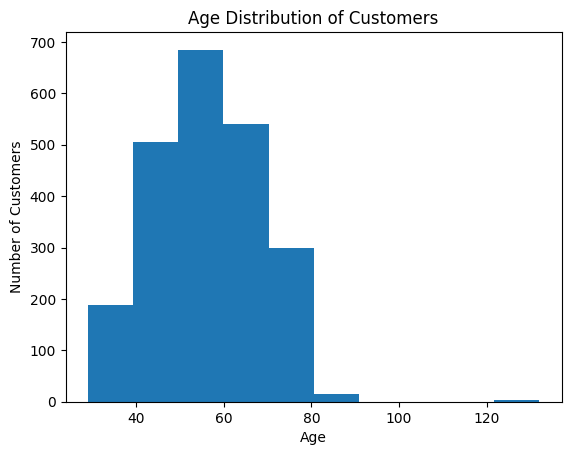

In [3]:
# Graph 1 -
plt.hist(data["Year_Birth"].apply(lambda x: 2025-x))
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

**Insight** - we can see that the customers age distribution is not  equal, and the most of the customers are between age 40- 65. so the bussiness focus dhould be on those communities.

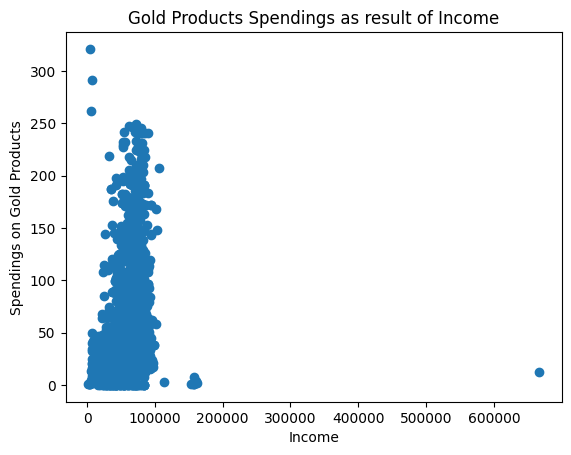

In [4]:
# Graph 2 -

plt.scatter(data["Income"], data["MntGoldProds"])
plt.title("Gold Products Spendings as result of Income")
plt.xlabel("Income")
plt.ylabel("Spendings on Gold Products")
plt.show()

**Insight** - we can say that except of several lone cases, there is a strong connection between a customer's income and the spendings of gold products. the lone cases are few people who have a large income but spend almost nothing on gold products and few people whose income is not updated and still spend a lot of gold products (can assume they earn a lot). so advertising gold products for higher income society seems like a good desicion.

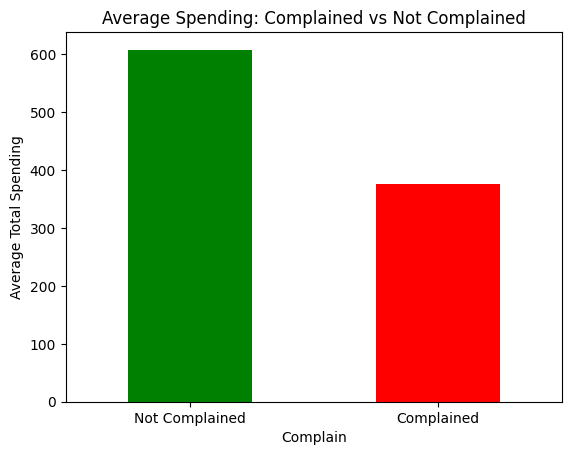

In [5]:
# Graph 3 -
# we create a total spent variable for each customer aggregates the sum of the customer spendings
data["TotalSpend"] = data[["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]].sum(axis=1)
# group by complains num (0 or 1) for each group calculate mean
avg_spend = data.groupby("Complain")["TotalSpend"].mean()
avg_spend.plot(kind="bar", color=["green","red"])
plt.title("Average Spending: Complained vs Not Complained")
plt.ylabel("Average Total Spending")
plt.xticks([0,1], ["Not Complained", "Complained"], rotation=0)
plt.show()


**Insight** - so we can see that customers who complained about the service in the past (even when speaking about only one time) spend by average much less then those who didn't comlain. meaning the satisfaction of the customer has a direct connection to the spendings.

## 2. KMEANS (30 points)

In this exercise, you will implement K-means clustering on a comprehensive customer dataset, to identify distinct customer segments.

*   Load the data again.
*   Scale the data using minmax scaler (2 points).
*   Encode categorical variables (3 points).
*   Apply k-Means algorithm on the 'MntMeatProducts' and 'MntWines' features using n_clusters=5
 (10 points).
*   Visualize the clusters (5 points).
*   Apply k-Means algorithm on all features and find the best k using 2 methods (10 points).
*   Visualize the methods (5 points).
* Note: There are some missing values. Describe how do you handle such.










In [6]:
# load the data
data = pd.read_csv("customer_segmentation.csv")


In [7]:
# Scale the data using MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

#first, there are missing values in income column, we set them to median.
median_income = data["Income"].median()
data["Income"] = data["Income"].fillna(median_income)

# drop the ID and Dt_Customer colunms to prevent misleading data
data = data.drop(columns = ['ID', 'Dt_Customer'])

scaler = MinMaxScaler()

# scale all the numeric colunms (except binary - already scaled)
numeric_columns = [
    'Year_Birth','Income','Recency',
    'Kidhome','Teenhome', 'MntWines','MntFruits',
    'MntMeatProducts','MntFishProducts','MntSweetProducts',
    'MntGoldProds','NumDealsPurchases','NumWebPurchases',
    'NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth'
]
data[numeric_columns] = scaler.fit_transform(data[numeric_columns])

# Encode categorical variables
# use get_dummies to split categorial variables to binaric columns.
# the removed column will be described by 0 in all others

encoded_data = pd.get_dummies(data, dtype = int)



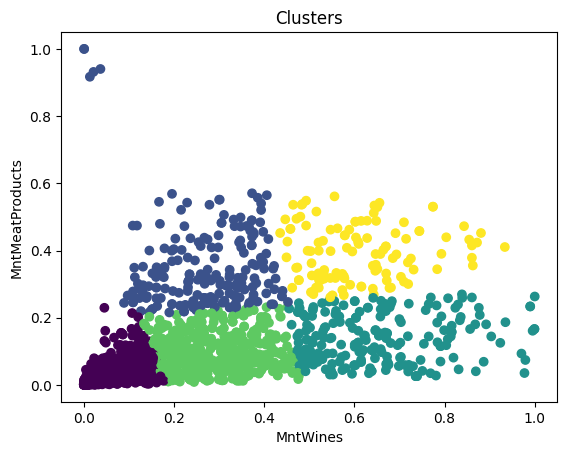

In [8]:
# Apply k-Means on the 'MntWines' and 'MntMeatProducts' features with n_clusters=5
from sklearn.cluster import KMeans
samples = encoded_data[["MntWines", "MntMeatProducts"]]
kmeans = KMeans(n_clusters=5)
kmeans.fit(samples)

# Visualize the clusters
plt.scatter(samples["MntWines"], samples["MntMeatProducts"], c=kmeans.labels_)
plt.title("Clusters")
plt.xlabel("MntWines")
plt.ylabel("MntMeatProducts")
plt.show()



### Elbow

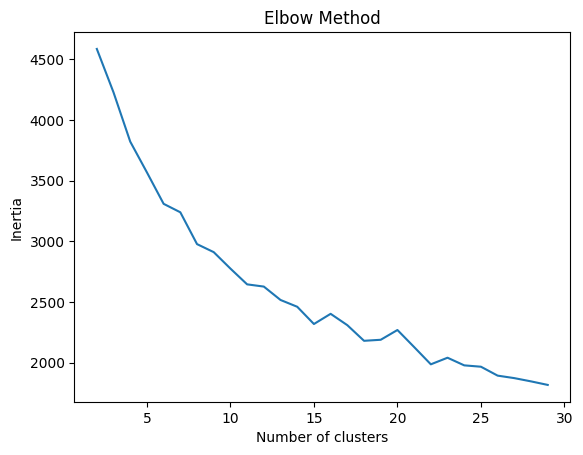

In [9]:
# apply k means on all the data
interia_results = []
features_num = len(encoded_data.columns)
# we will limit the cluster range to 30 to ease the running time and it will be enough to identify the elbow
for k in range (2, 30):
  kmeans = KMeans(n_clusters = k)
  kmeans.fit(encoded_data)
  interia_results.append(kmeans.inertia_)

plt.plot(range(2, 30), interia_results)
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# insight after results - we can see the elbow is around 15 - 20


### Silhouette Score

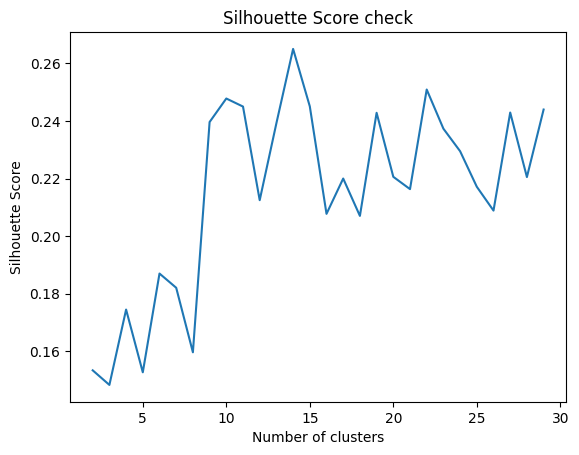

In [10]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 30):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(encoded_data)
    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(encoded_data, labels))


plt.plot(range(2, 30), silhouette_scores)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score check')
plt.show()

# insight after run - the silhouette score is very low, probably because of the many variables created while encdoing



## 3. PCA (15 points)
In this exercise, you will implement PCA:
*   With n_components = 2 (5 points).
*   Visualize the PCA (5 points).
*   Find the variance explined in this PCA (5 points).





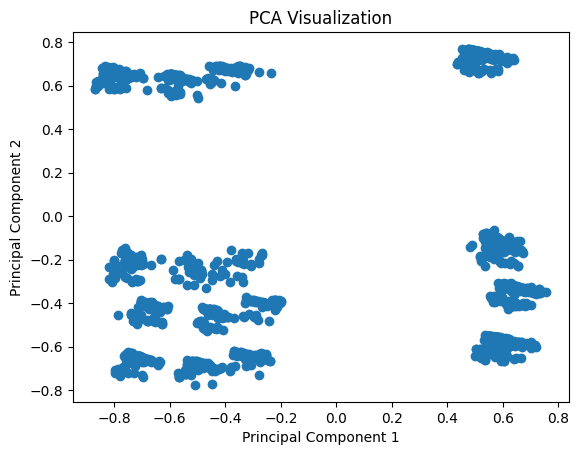

Explained Variance:
PC1: 0.14641966494898742
PC2: 0.13809794462171923
Total: 0.28451760957070665


In [11]:
# Adjust n_components as needed
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

# Create a DataFrame with the principal components

data_after_pca = pca.fit_transform(encoded_data)
data_frame_pca = pd.DataFrame(data_after_pca, columns=['PC1', 'PC2'])

# Visualize the PCA

plt.scatter(data_frame_pca['PC1'], data_frame_pca['PC2'])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization')

# Plotting the PCA
plt.show()


# find and Display explained variance
explained_variance = pca.explained_variance_ratio_
print("Explained Variance:")
print("PC1:", explained_variance[0])
print("PC2:", explained_variance[1])
print("Total:", explained_variance.sum())



**Q**: What is the variance explained in the 2 component PCA?

**A**:the total variance explained in the 2 component pca is 0.28 of the data

## 4. PCA & Kmeans (20 points)
This time, we will use the PCA data for the kmeans model.
*   Run PCA with n_components = 2 (5 points)
*   Find the best k for kmeans (5 points)
*   Plot the best clusters (5 points)
*   Answer the questions (5 points)





In [12]:
# PCA with 2 components + DataFrame with the principal components
pca = PCA(n_components=2)
data_afet_pca = pca.fit_transform(encoded_data)
data_frame_pca = pd.DataFrame(data_afet_pca, columns=['PC1', 'PC2'])


### Elbow

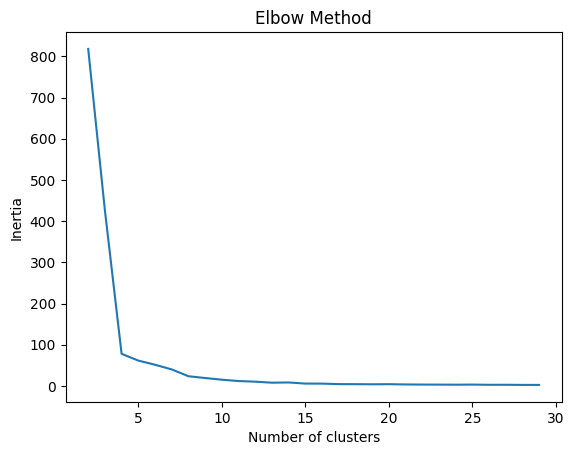

In [13]:
# best k for k means with elbow, based on data after pca
interia_results = []
# we will limit the cluster range to 30 to ease the running time and it will be enough to identify the elbow
for k in range (2, 30):
  kmeans = KMeans(n_clusters = k)
  kmeans.fit(data_frame_pca)
  interia_results.append(kmeans.inertia_)

plt.plot(range(2, 30), interia_results)
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

### Silhouette

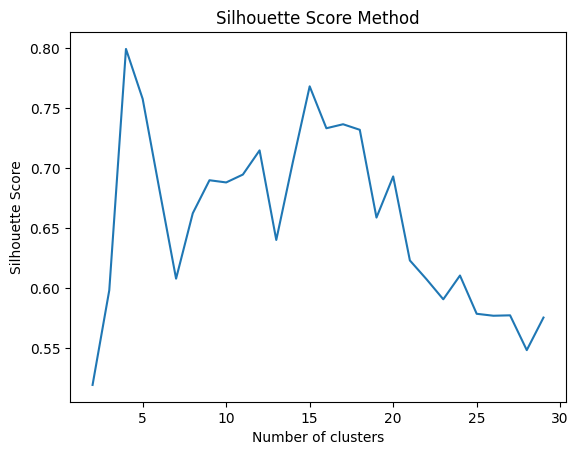

In [14]:
# Silhouette score for k clusters based on data after pca
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 30):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(data_frame_pca)
    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(data_frame_pca, labels))


plt.plot(range(2, 30), silhouette_scores)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Method')
plt.show()


**plot the best clusters part: (we added this cell)**

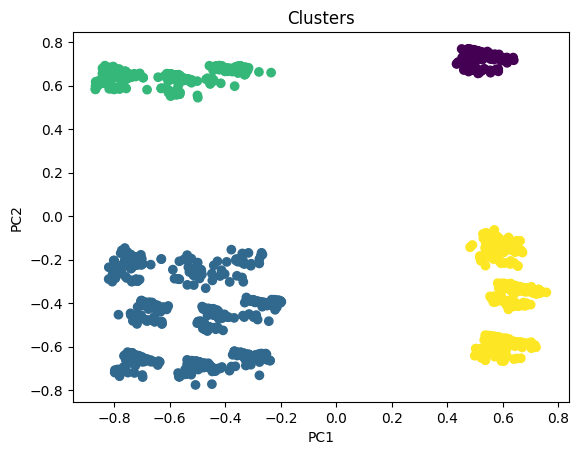

In [15]:
# choose best k based on elbow and silhouette and plot the clusters
# we chose k = 4 because by elbow the best k is around 4 and by silhouette the same
# from the global maximum. the value of 4 is around 0.8
selected_k = 4
kmeans = KMeans(n_clusters=selected_k)
kmeans.fit(data_frame_pca)

# Visualize the clusters
plt.scatter(data_frame_pca['PC1'], data_frame_pca['PC2'], c=kmeans.labels_)
plt.title("Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**Q**: In our human eye, it's looks like we need 5 clusters. But both methods return 2. Why do you think kmeans returning 2 and not 5?

**A**: in our case, the methods return k = 4, and you can see with the plotting above that it gives a great clustering. there is a large split to 2 groups by pc1 and an inner split by PC2 - those 2 splits create 4 clear clusters. we might look at the categories and think that 5 clusters will represents better, but as it looks k = 4 is an accurate clustering.

## Q: Did dimensionality reduction improve clustering quality?

Justify your answer based on silhouette scores and visualization.

## A: your answer here
we can see that pca improved the clustering (there are more k's who achieve better results now), and a better max result of 0.8 (for k = 4).

## 5. K-means Clustering Exercise (10 points)
Manually divide a given set of points into clusters using the K-means clustering.

You are given the following two-dimensional points: <br>
*   A:(2,2)
*   B:(2,6)
*   C:(3,7)
*   D:(5,5)
*   E:(6,2)
*   F:(7,4)
*   G:(8,7)

**Tasks:**
1.   **Visualize the Data**: Plot these points and label each point for easy identification (3 points).
2.   **Choose Initial Cluster Centers**: Arbitrarily select three points as initial cluster centers (For example, you might choose points A and D) and **Answer the questions** (7 points).











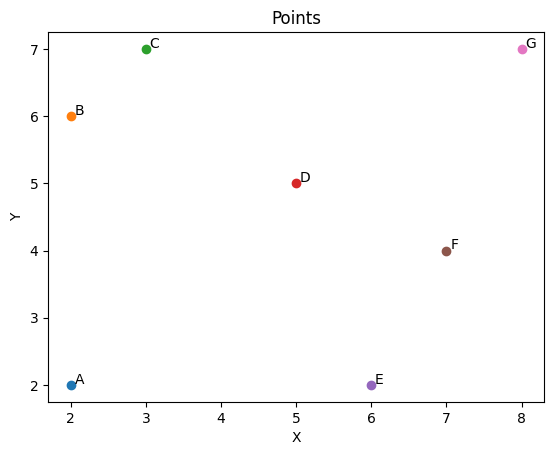

In [16]:
# points plot
points = {
    'A': (2,2),
    'B': (2,6),
    'C': (3,7),
    'D': (5,5),
    'E': (6,2),
    'F': (7,4),
    'G': (8,7)
}
for letter, (x,y) in points.items():
    plt.scatter(x, y)
    plt.text(x + 0.05, y+ 0.02, letter)
plt.title("Points")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

**Questions**:
1.   How did the points group together in the final iteration?
2.   Was choosing different initial cluster centers leading to different final clusters? Why might this happen?
3.   Think of any real-world scenarios where K-means clustering could be useful?






**Answers**:
1. c1 = {A}, c2 = {B, C, D, E, F}, c3 = {G}
2. yes, because kmeans starts with random centroids and clusters according to distance from those centroids and then updates the centroids to be the center of the cluster. therefore there is a continious effect to the centroid choice at the beggining.
3. one example is anomaly detection, for example in credit frauds.knowing how to recognize something "different" then other examples without clear definition of parameter to check before, can help identifying many kinds of suspicous cases.


**The calculation way of question 5: (uploaded to colab as 3 png files)**

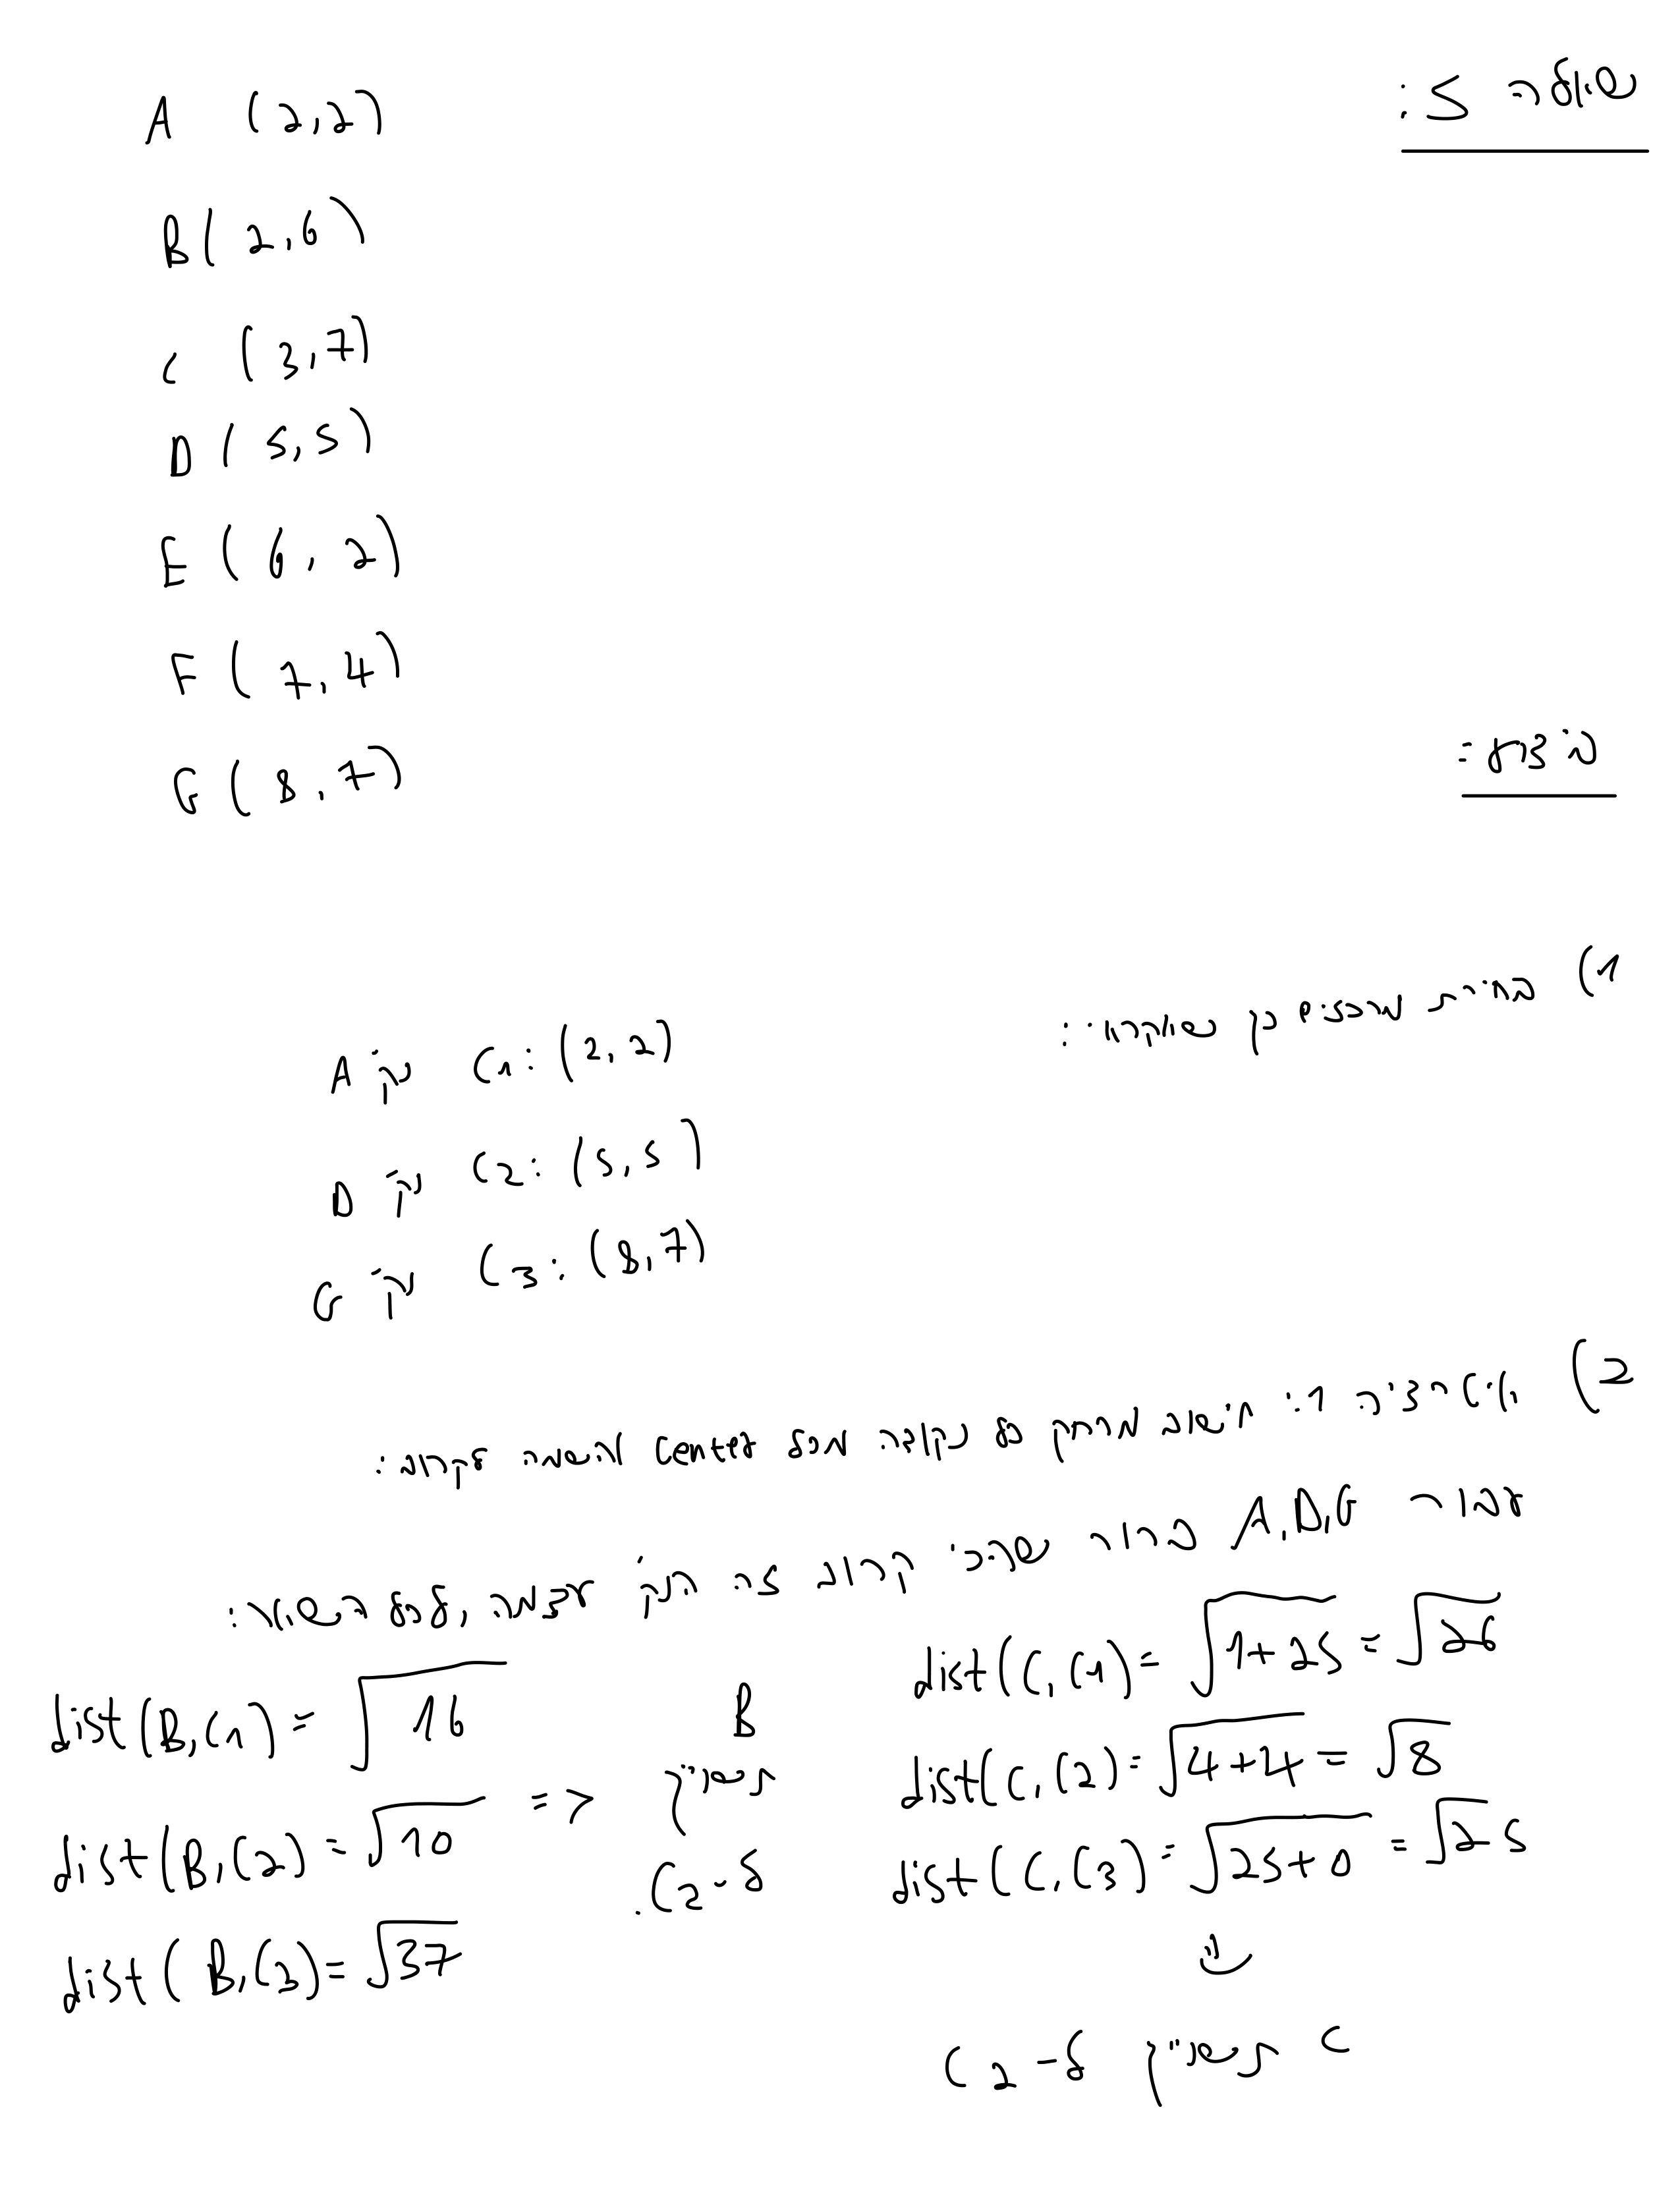

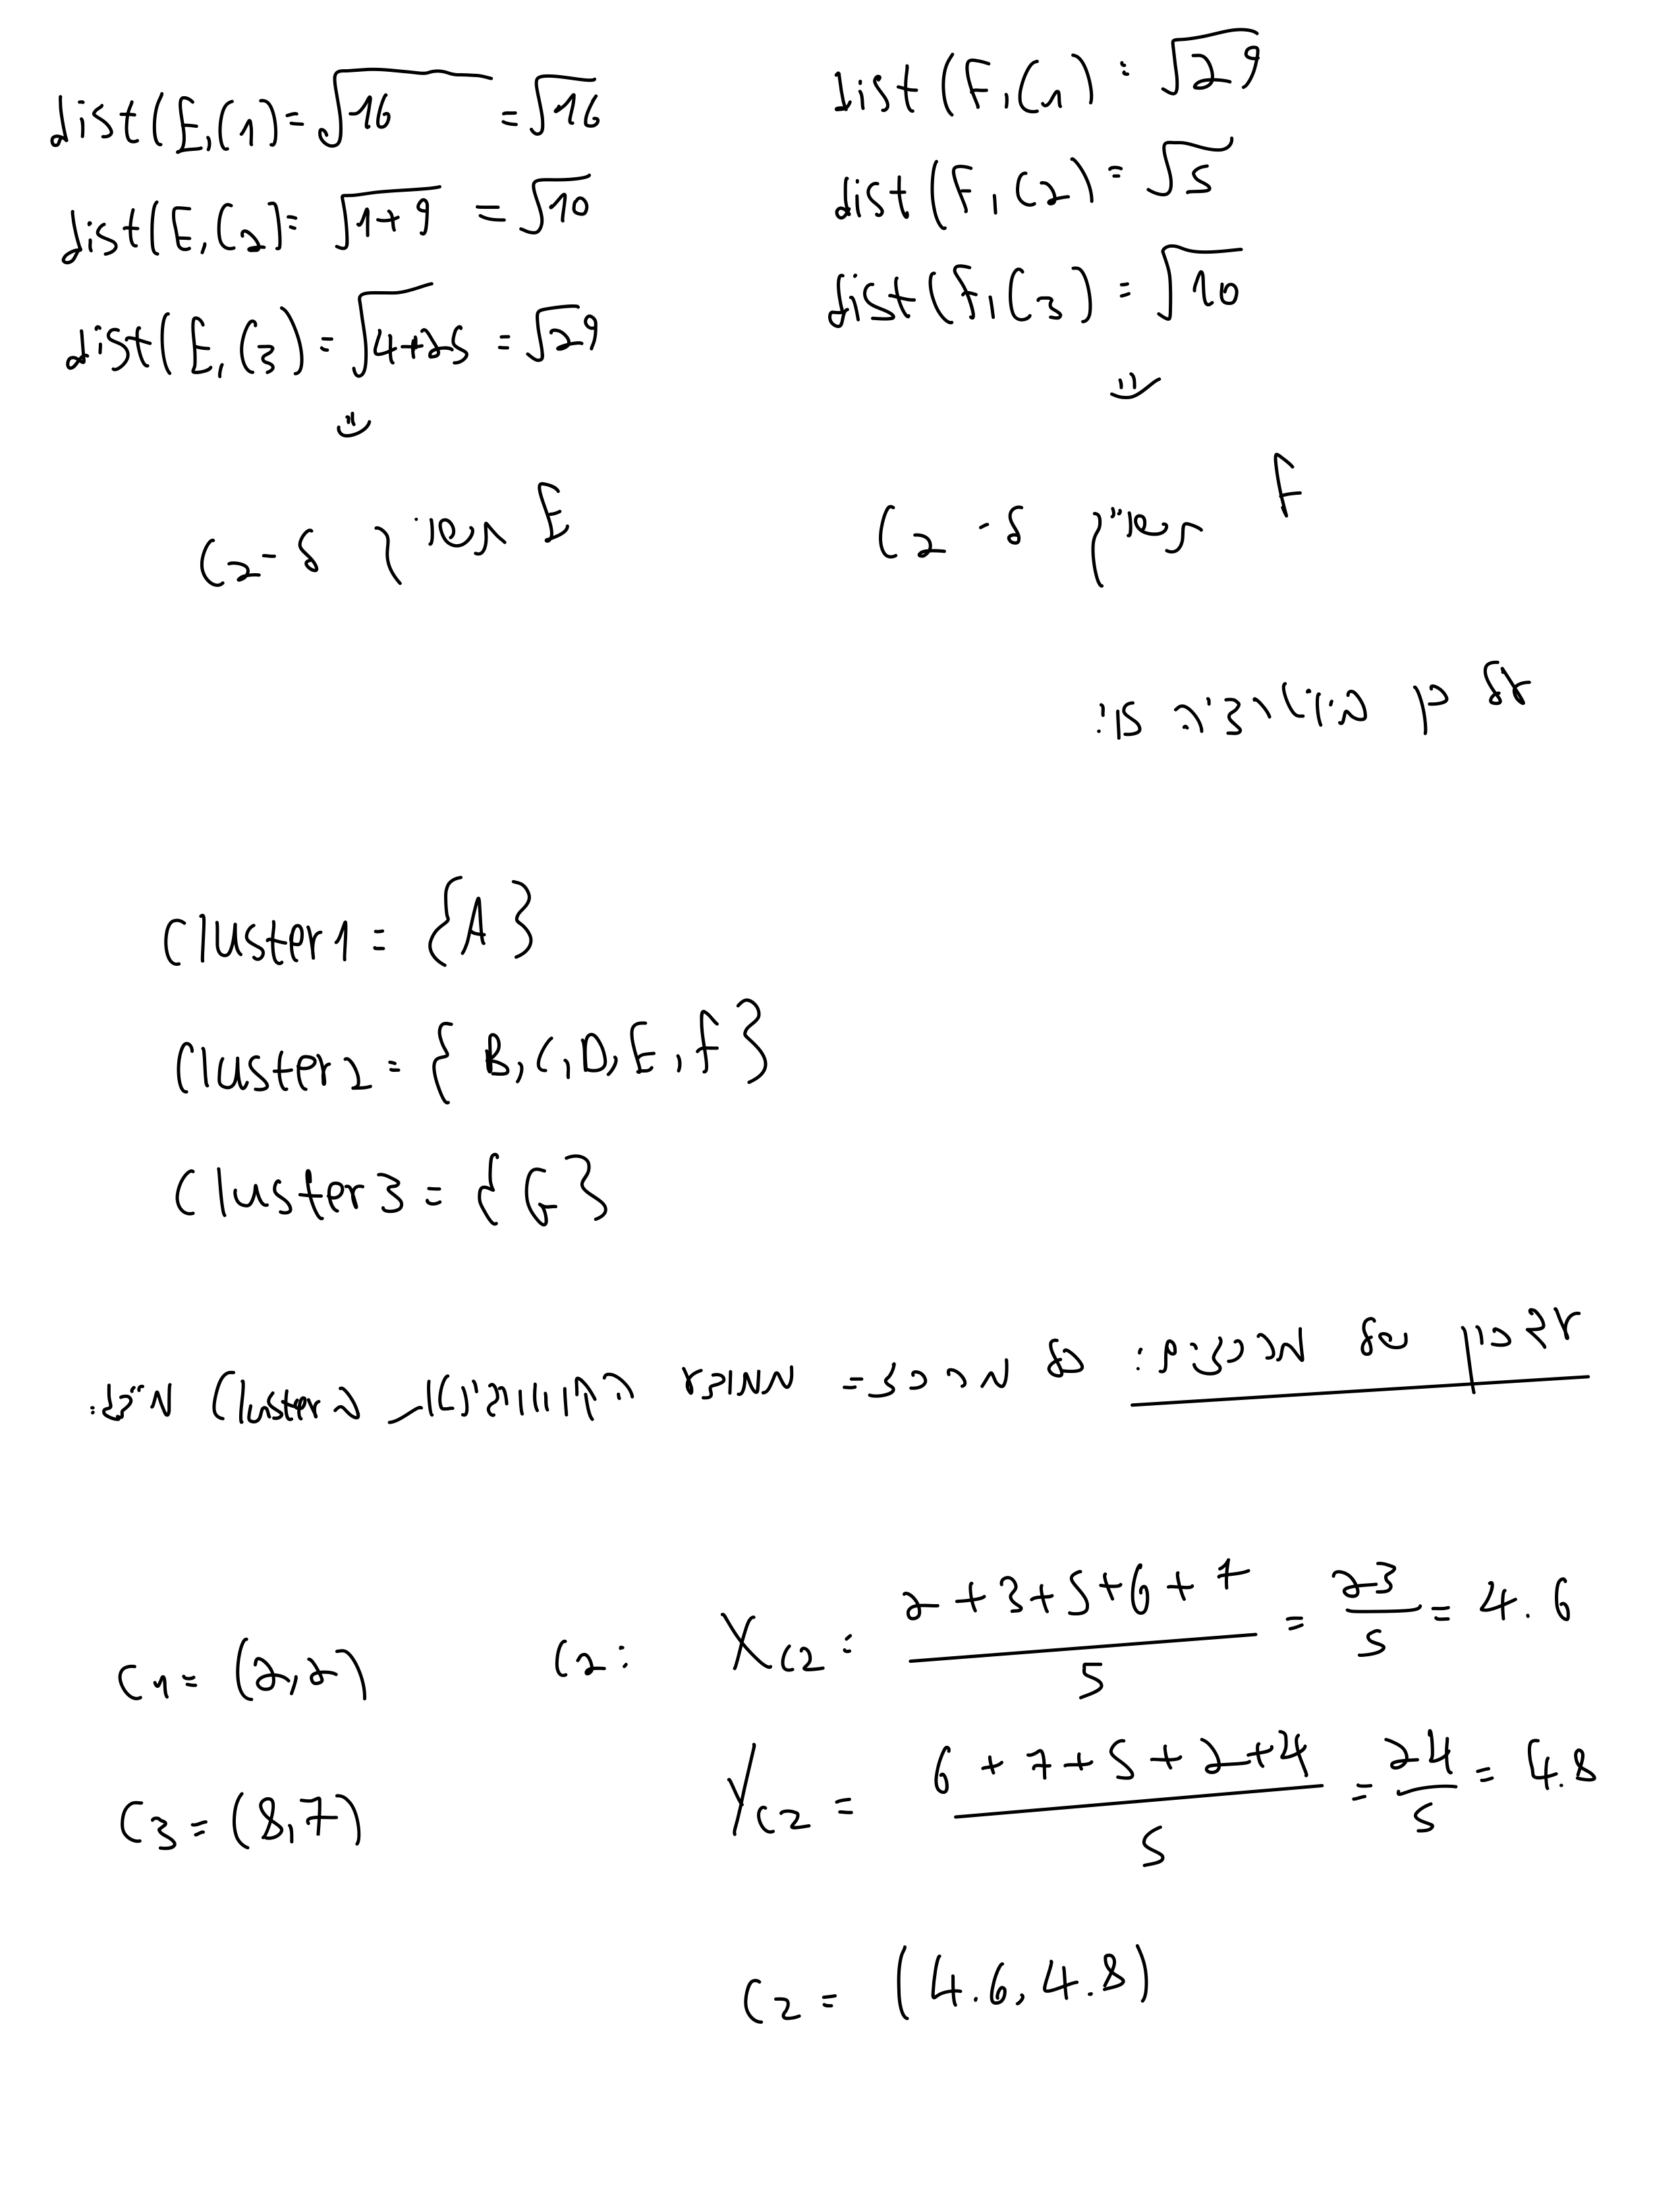

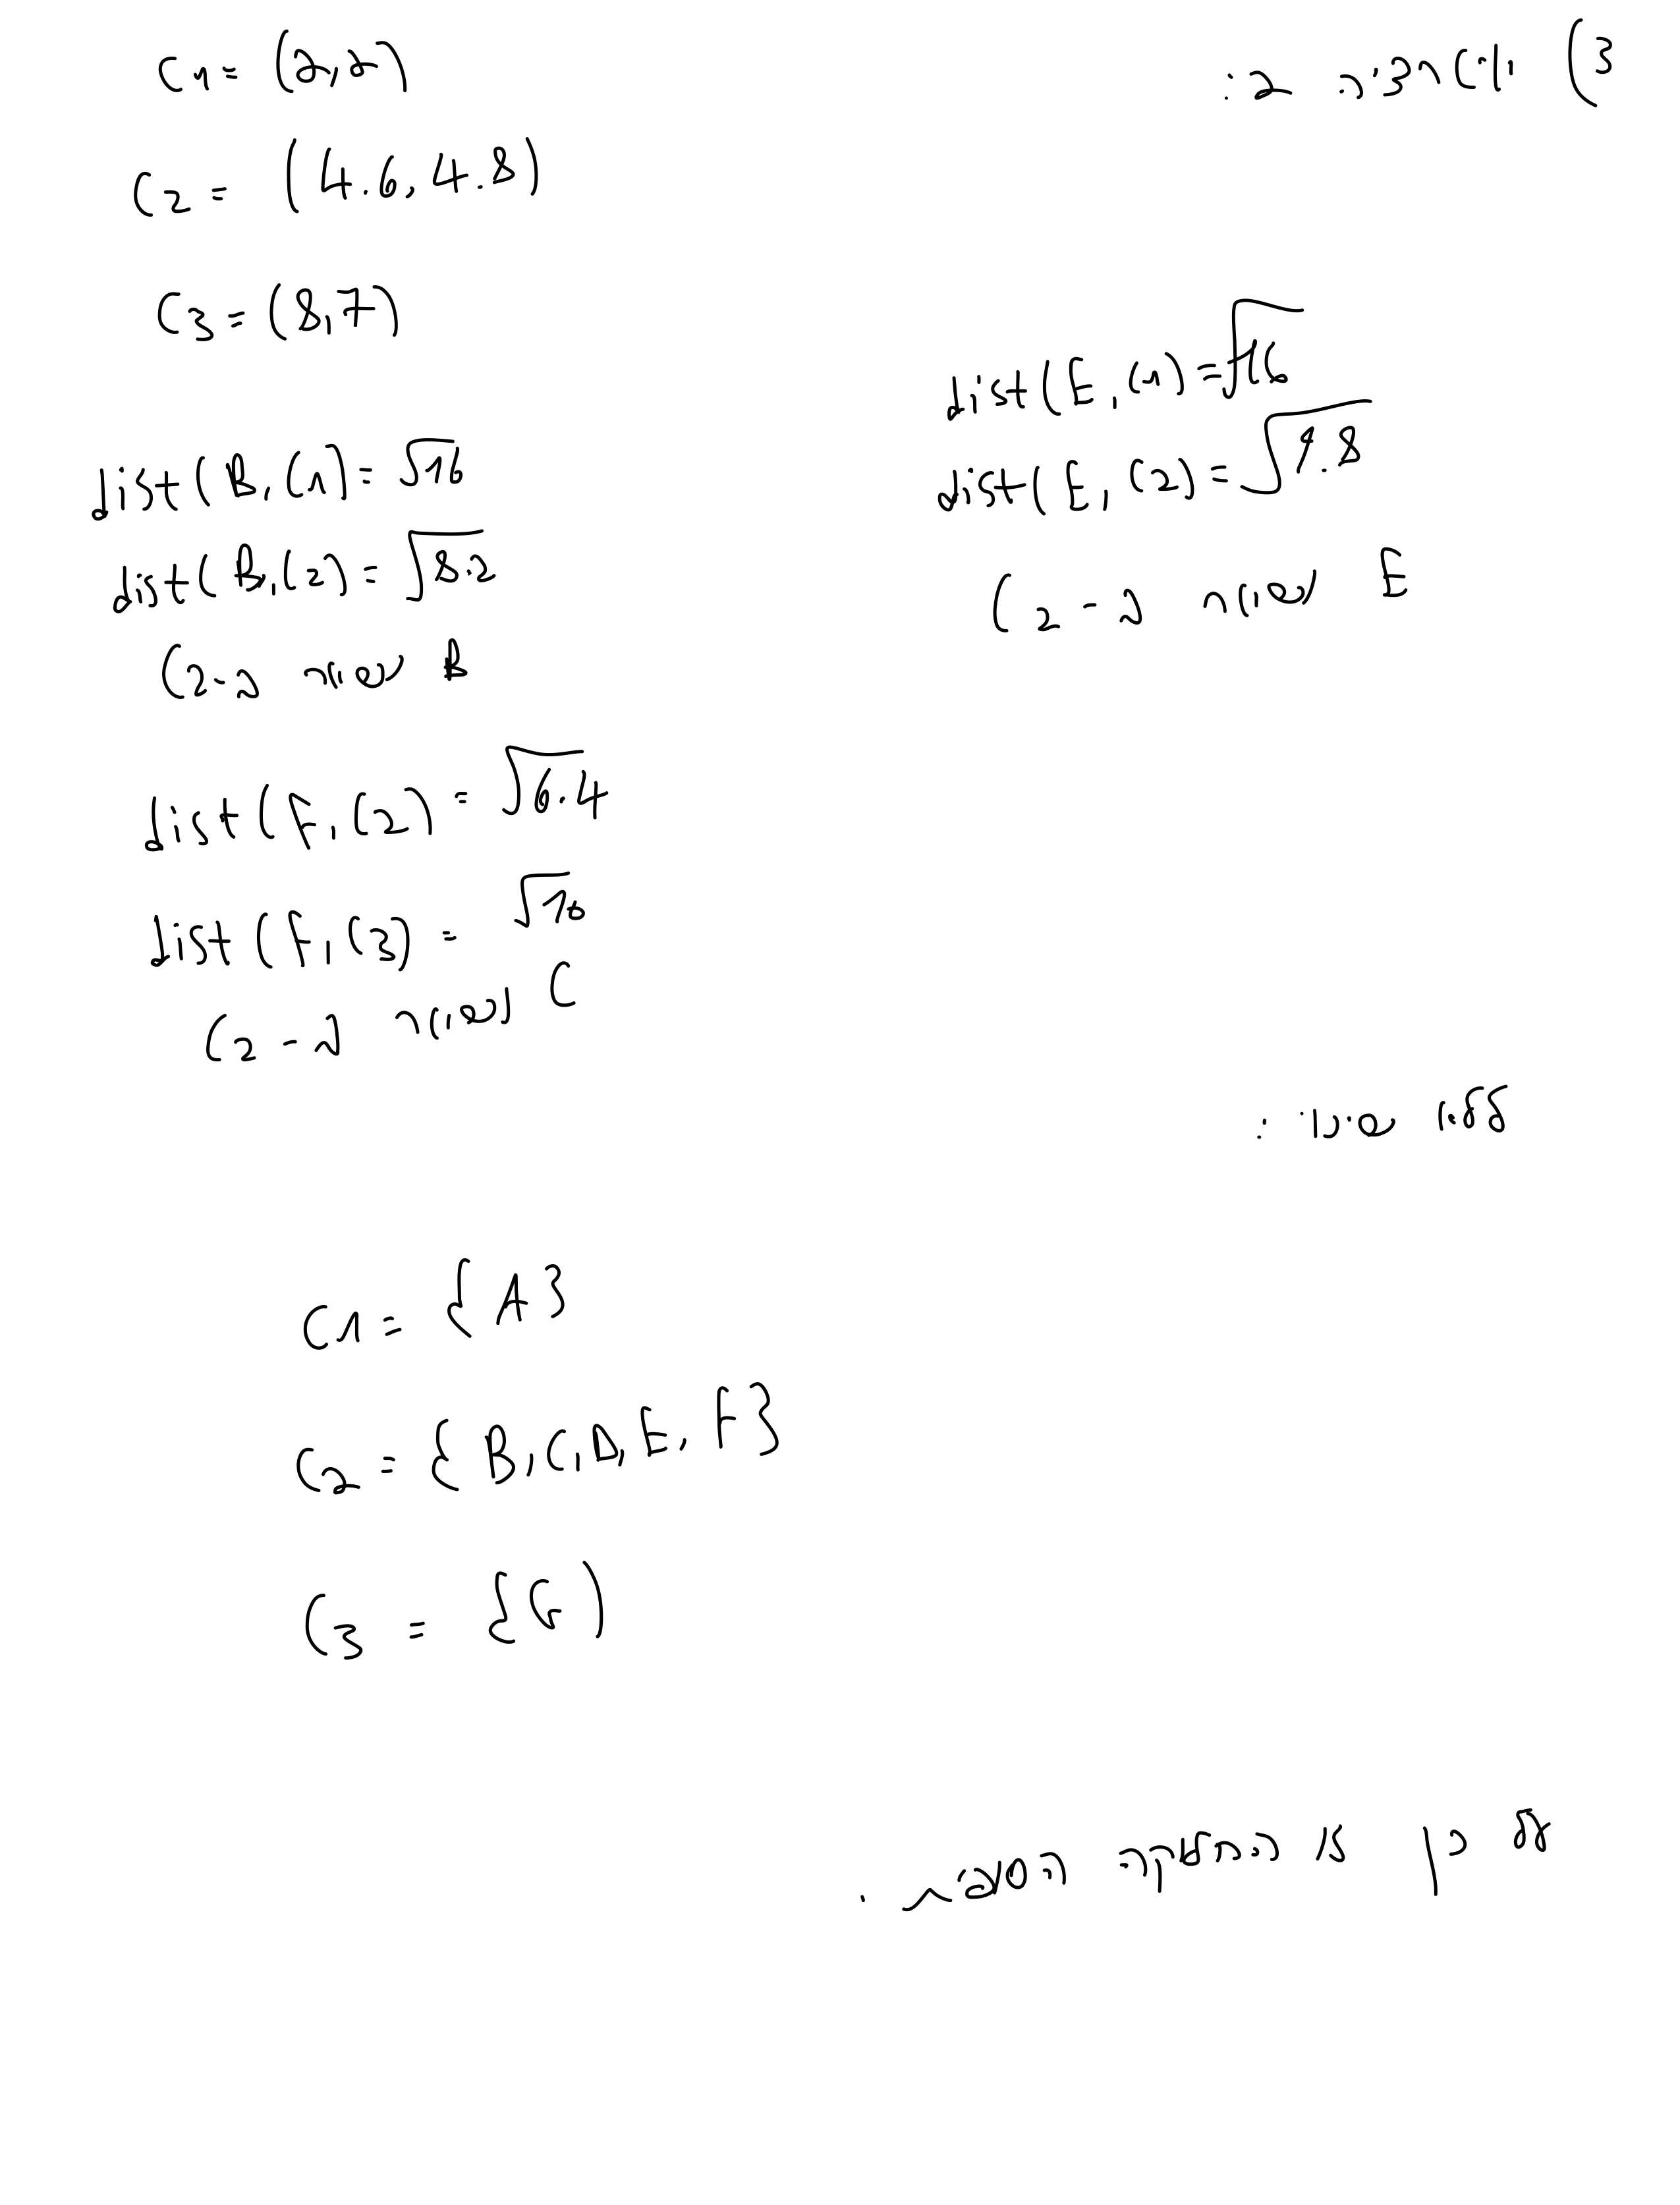

## 6. Principal Component Analysis (PCA) (10 points)
You are given a dataset with 5 rows and 5 columns as shown below. Perform Principal Component Analysis (PCA) on this dataset.

$\begin{pmatrix}
2 & 0 & 1 & 3 & 4\\
1 & 1 & 0 & 2 & 1\\
3 & 2 & 1 & 0 & 5\\
4 & 3 & 2 & 1 & 2\\
5 & 1 & 3 & 4 & 0\\
\end{pmatrix}$

**Tasks:**
1.   **Code**: Compute the eigenvectors using the PCA package from sklearn. (3 points).
2.   **On paper**: Project the dataset onto (1) A 1-dimensional space (first principal component). (2) A 2-dimensional space (first and second principal components). (7 points).

In [17]:
# eigenvectors computaion with pca package
matrix = np.array([
    [2, 0, 1, 3, 4],
    [1, 1, 0, 2, 1],
    [3, 2, 1, 0, 5],
    [4, 3, 2, 1, 2],
    [5, 1, 3, 4, 0]
])
pca = PCA()
pca.fit(matrix)
print(pca.components_)

[[-0.36816003  0.05031372 -0.32020271 -0.47984702  0.7274227 ]
 [ 0.64138932  0.50697837  0.36436685 -0.40743821  0.18117277]
 [ 0.30637208 -0.44922196  0.29906659  0.46991222  0.62775589]
 [-0.41209239  0.68590034  0.24825357  0.5115773   0.1907339 ]
 [-0.43519414 -0.26111648  0.78334945 -0.34815531 -0.08703883]]


\
**Answer**: Projection result for 1D =
\begin{pmatrix}
 1.109\\
 0.146\\
 3.009\\
-0.29\\
-3.974
\end{pmatrix}



\
**Answer**: Projection result for 2D =
\begin{pmatrix}
 1.109 & -1.614\\
 0.146 & -2.249\\
 3.009 &  1.444\\
-0.29 &  2.006\\
-3.974 &  0.413
\end{pmatrix}


**The Calculation Way:** uploaded to colab as 2 files of PNG:

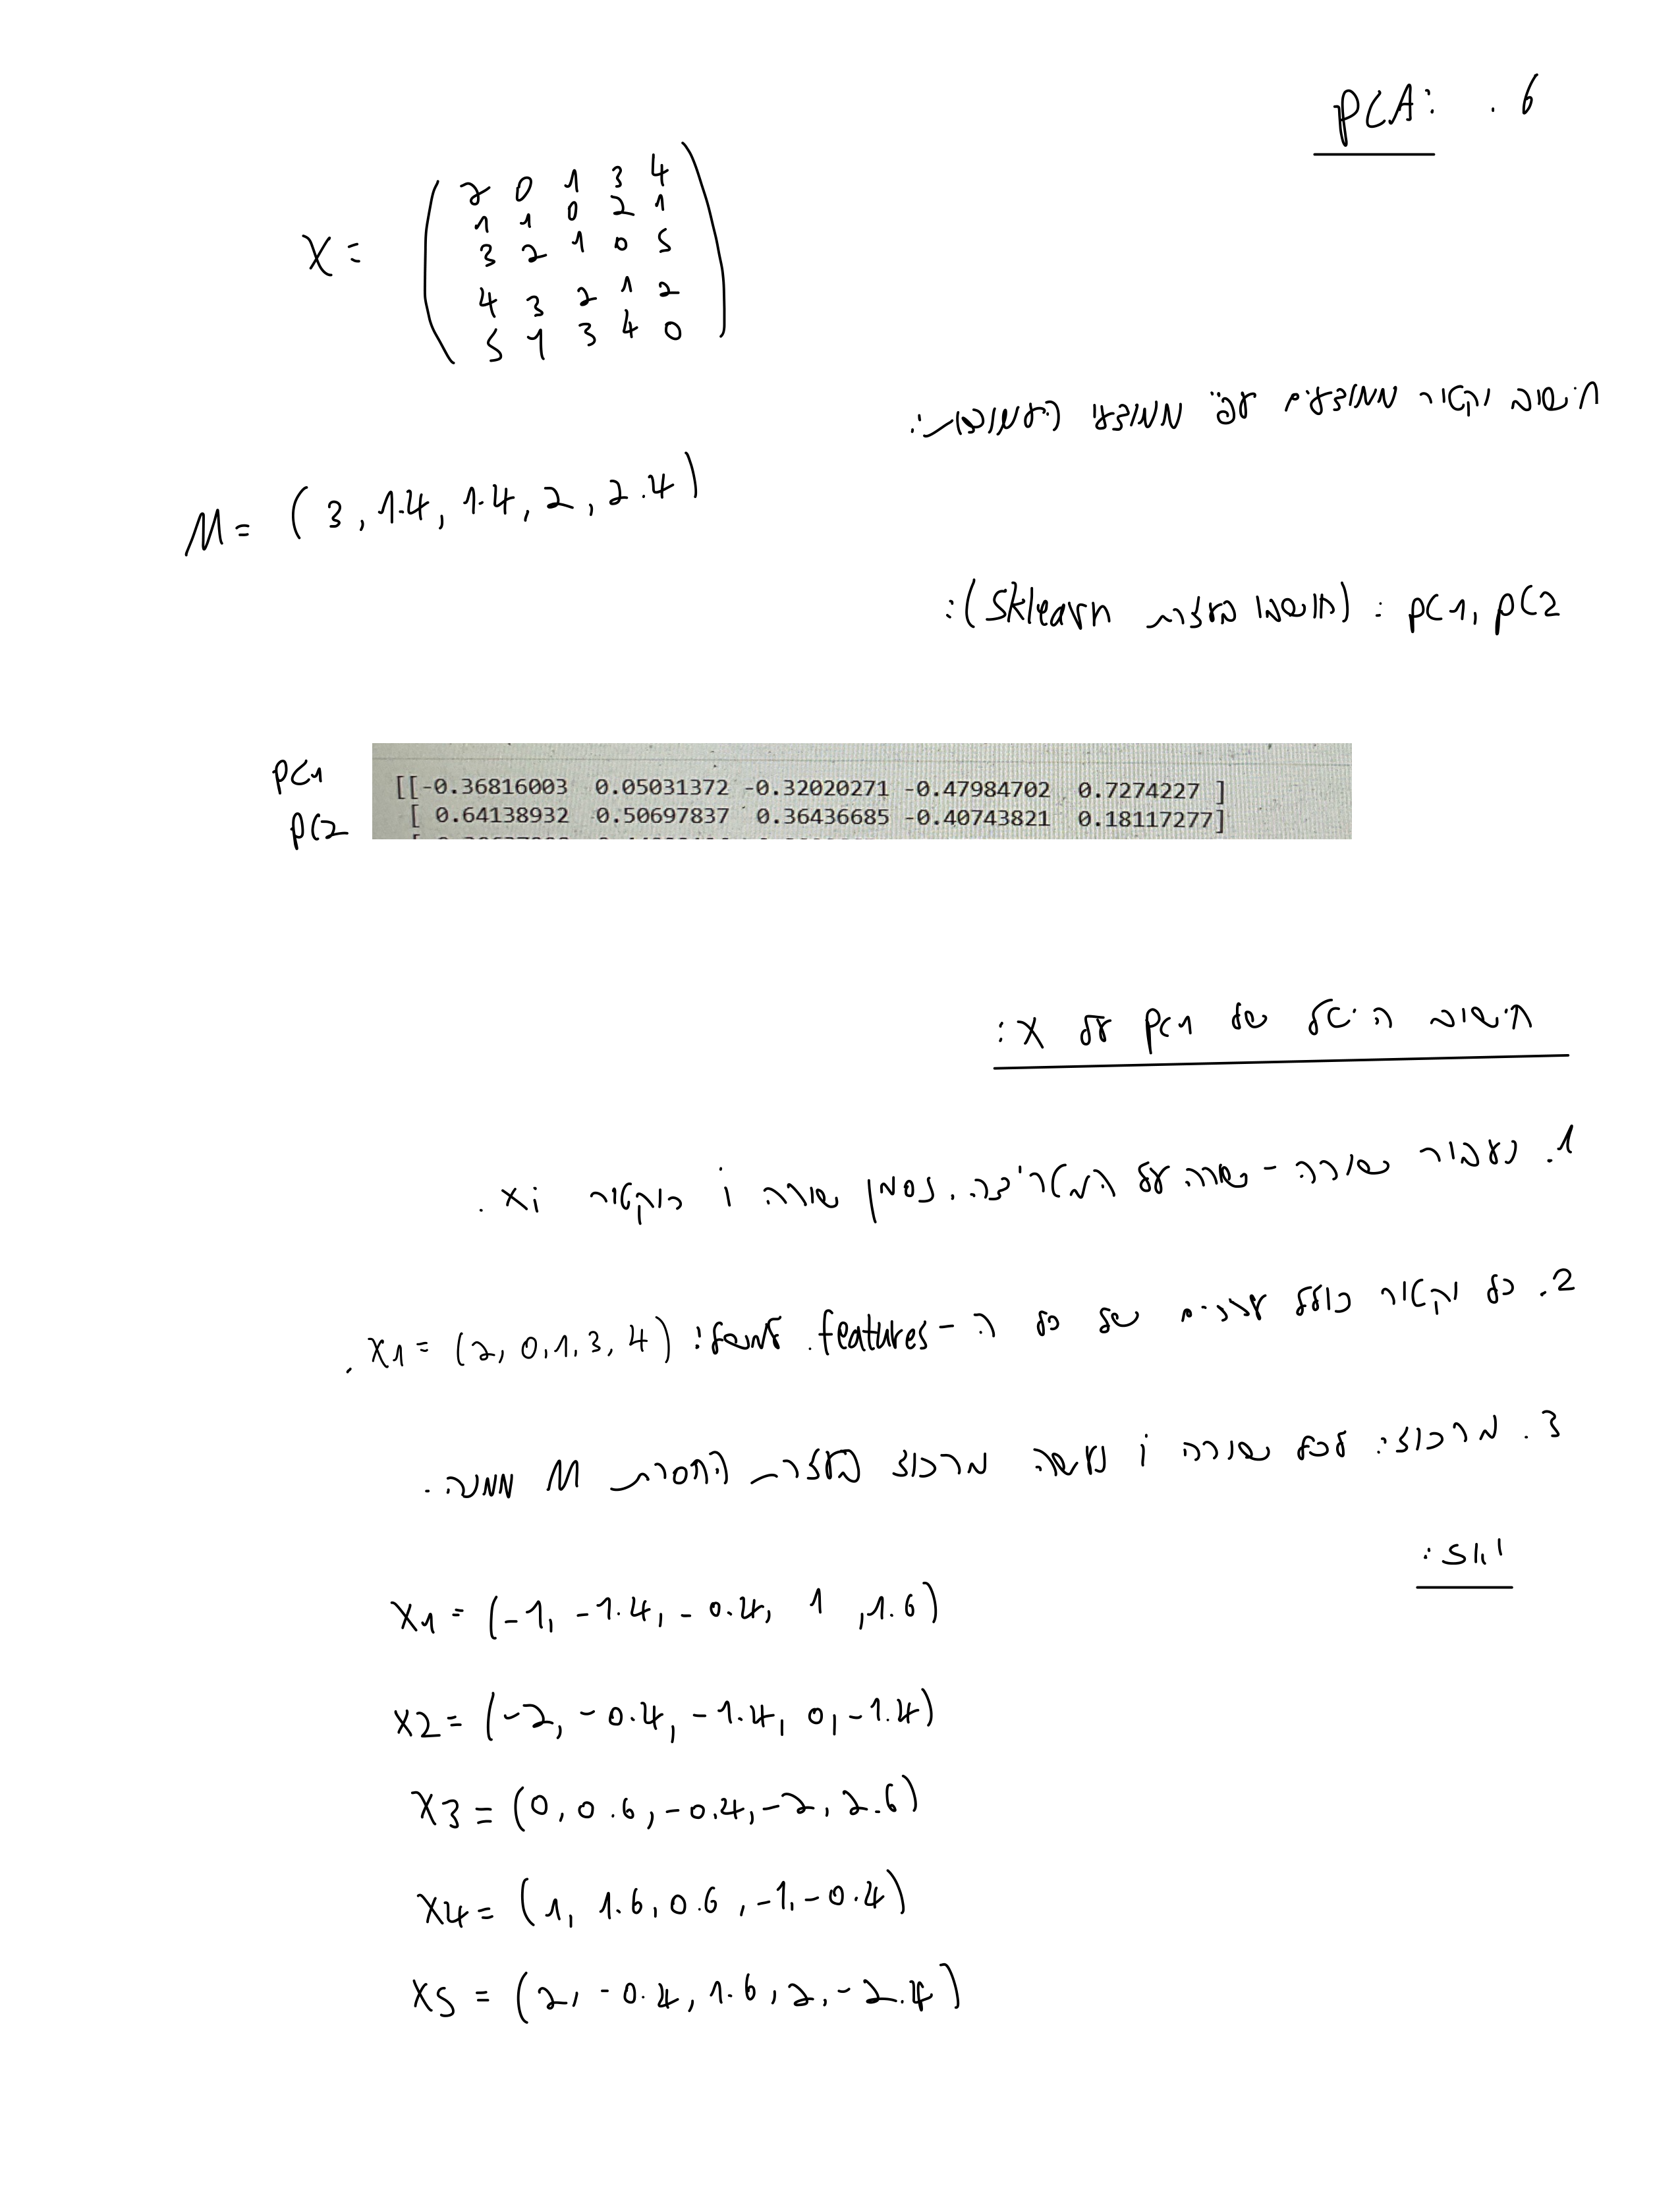

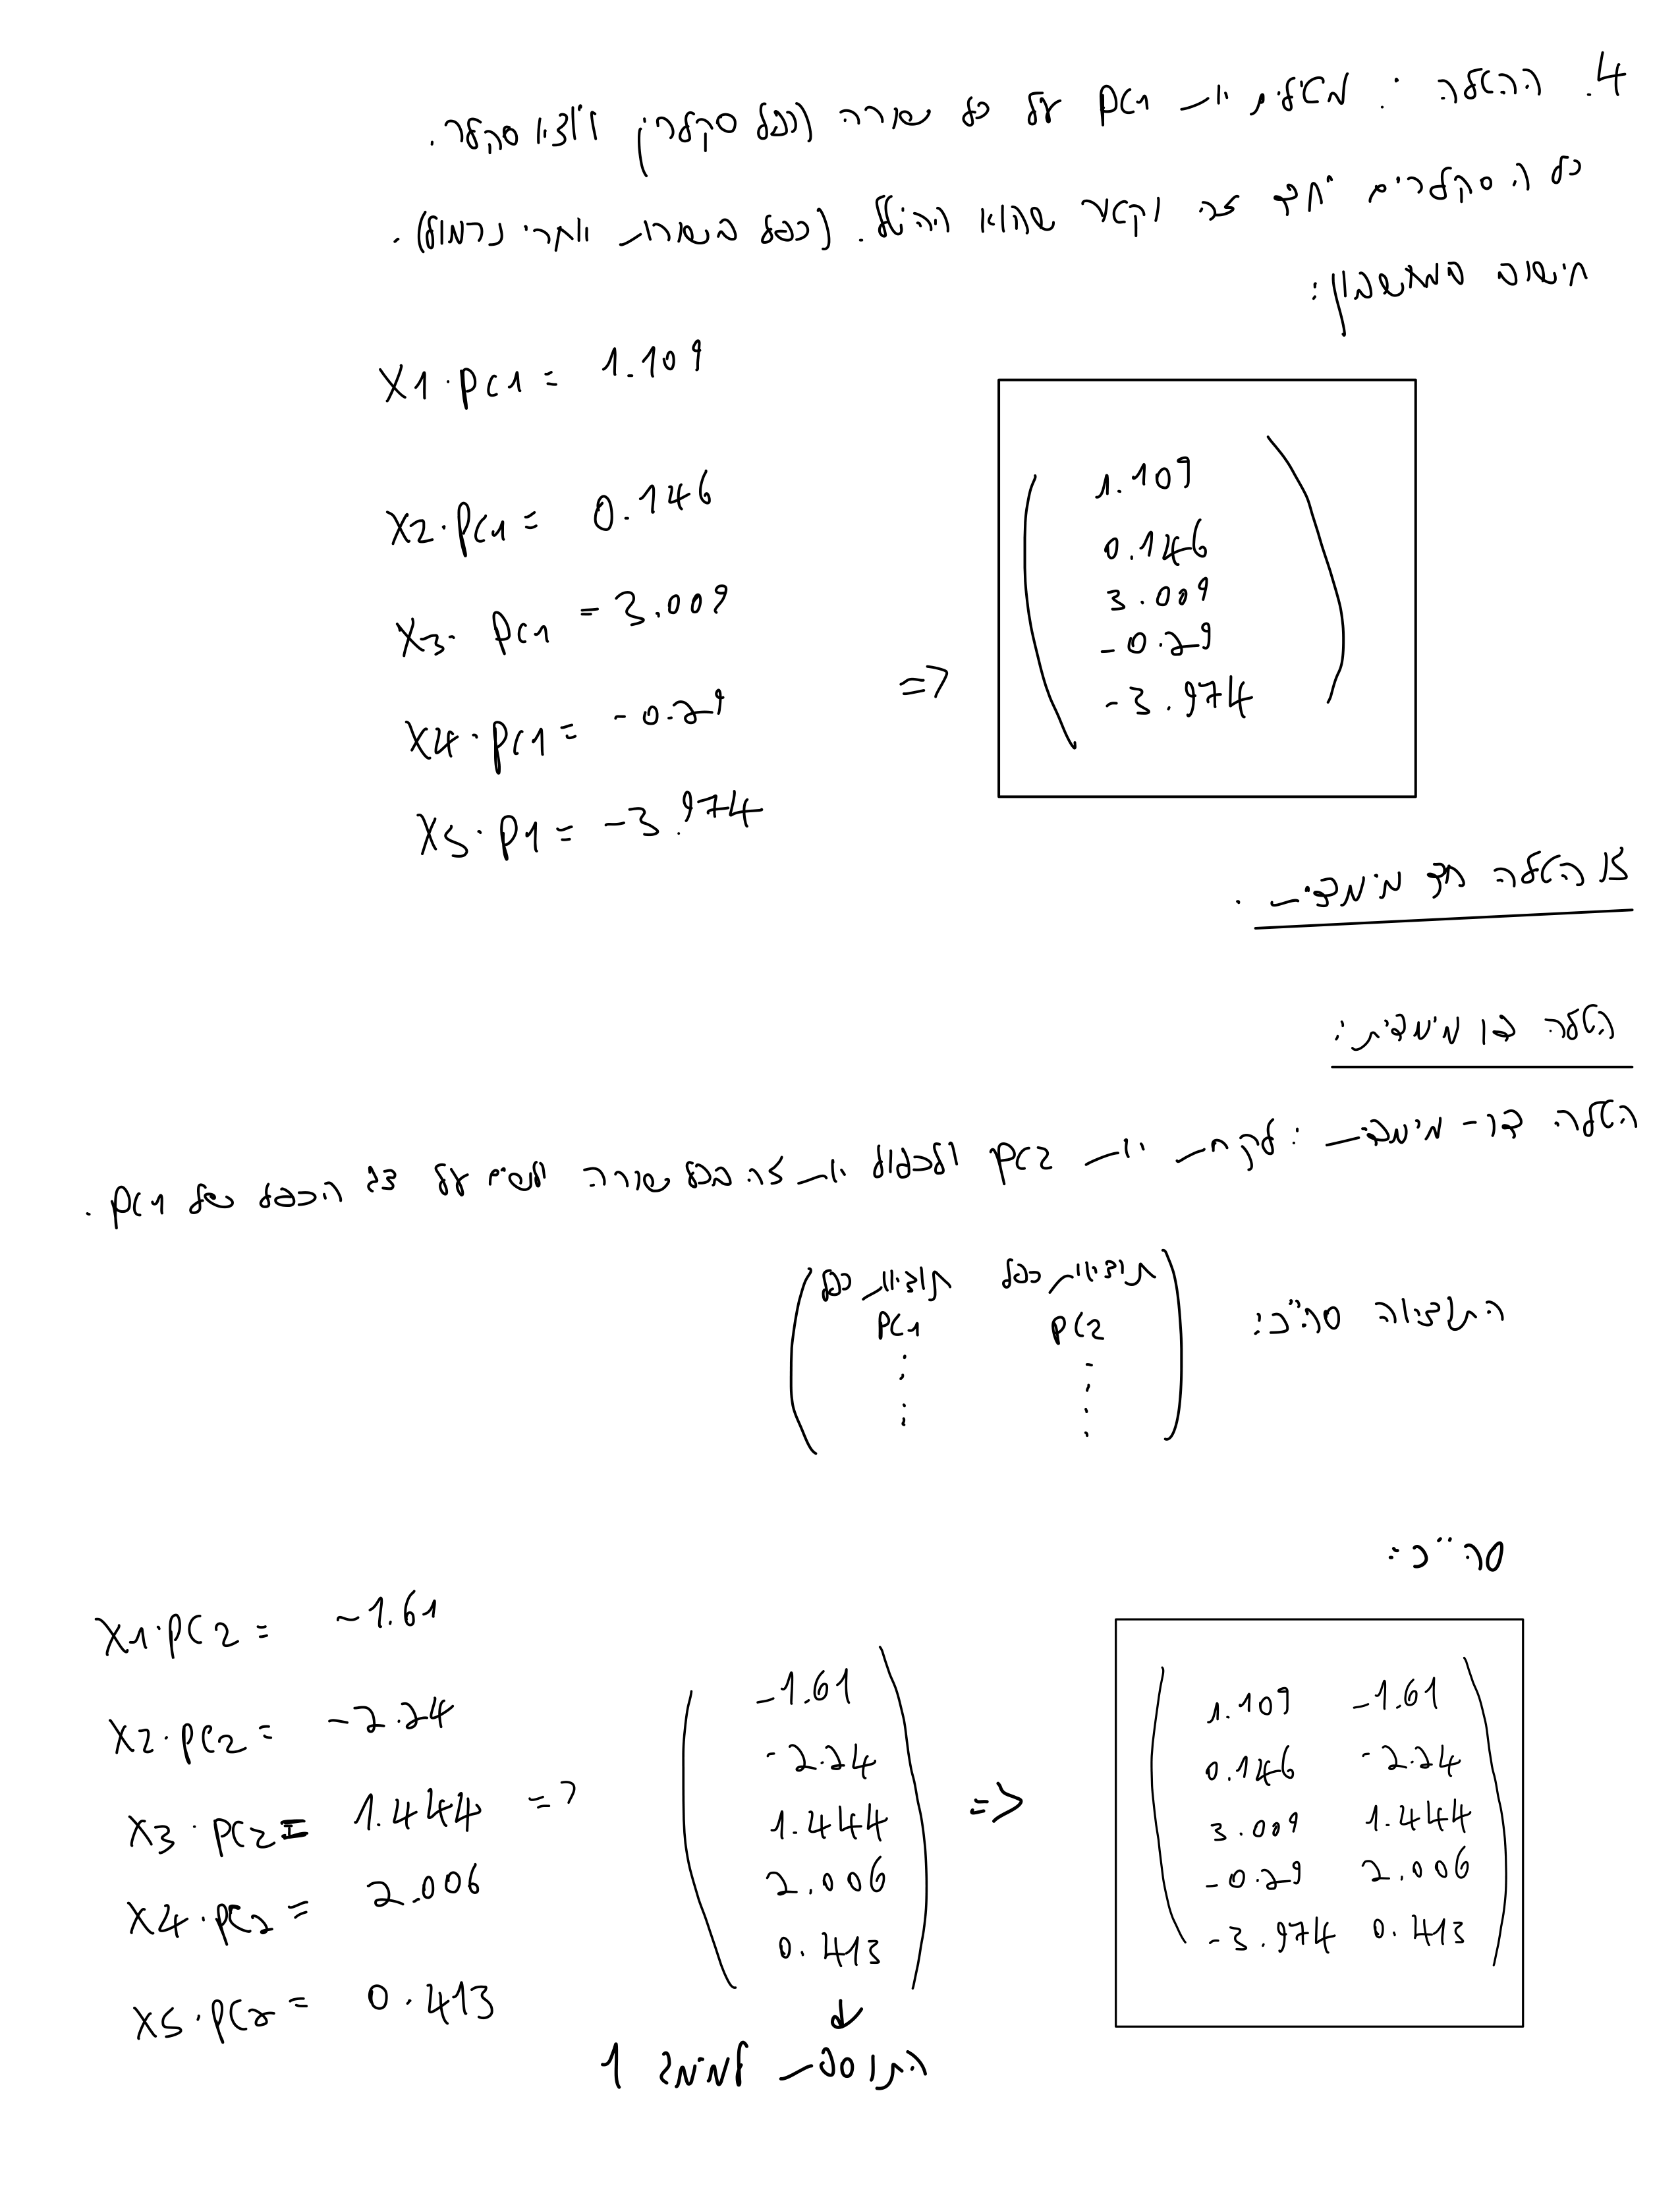

## 7. What are the limitations of PCA in high-noise settings?

first, PCA considers variance as indication to importance. high noise settings may cause variance which isn't originated in the data and PCA might give it importance at treat that as an indication to principal component.

plus, PCA might sruggle dealing with not-linear noise because it is based on linear relationships.